<a href="https://colab.research.google.com/github/glisserok/grigoriyvolkov/blob/main/Laba3_KSVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_20135/3165725673.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='track_name', data=top_10_songs, palette='viridis')


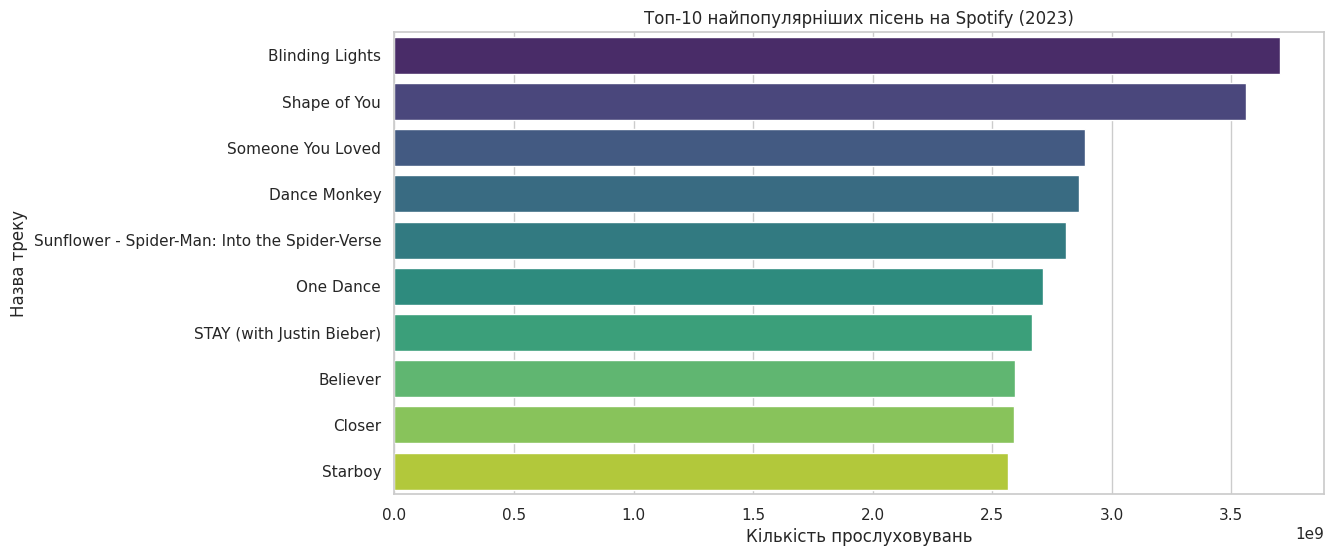

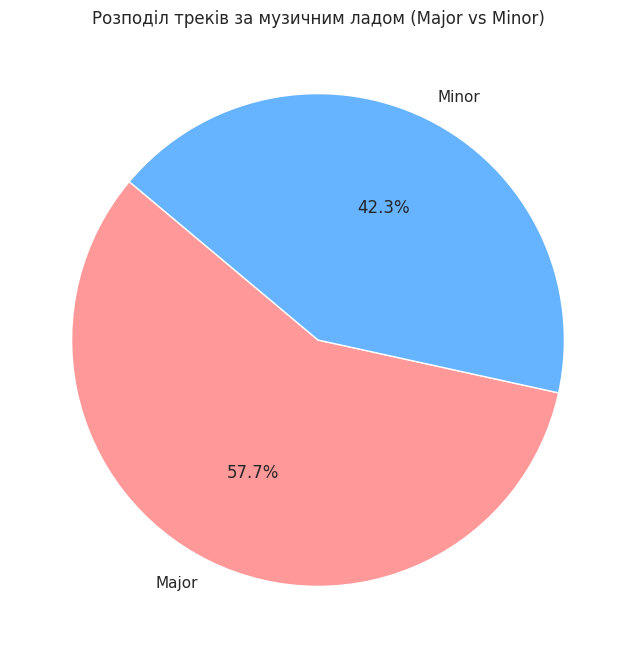

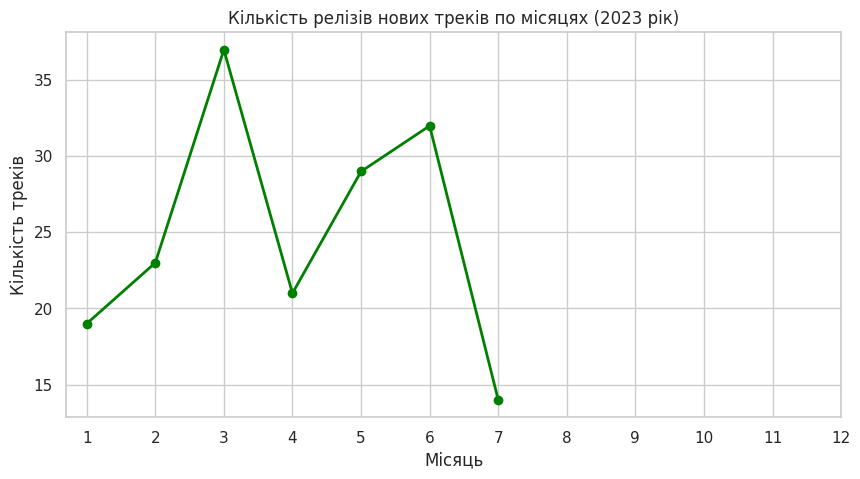

/tmp/ipykernel_20135/3165725673.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='artist(s)_name', data=top_artists, palette='magma')


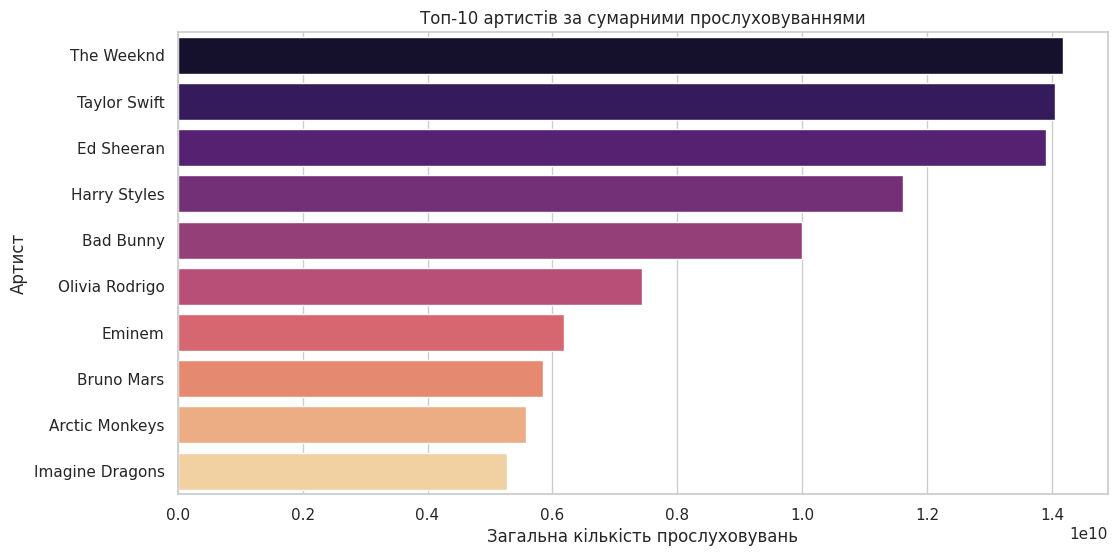

/tmp/ipykernel_20135/3165725673.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='track_name', data=selected_tracks, palette='coolwarm')


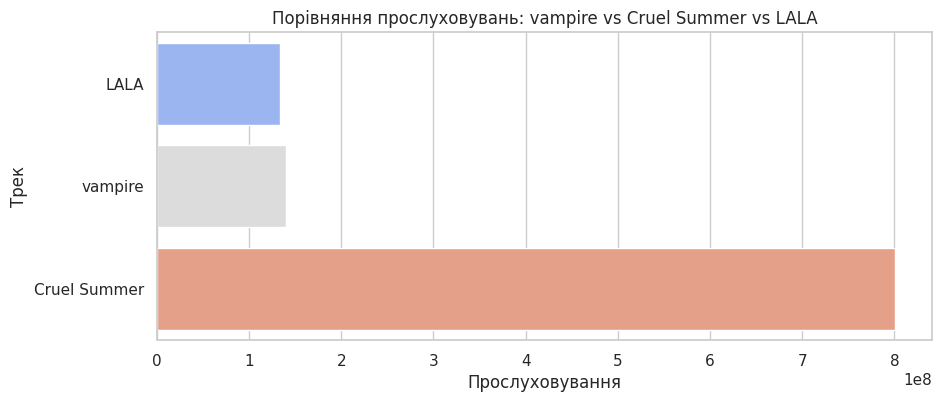

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams'])

sns.set_theme(style="whitegrid")

top_10_songs = df.nlargest(10, 'streams')

plt.figure(figsize=(12, 6))
sns.barplot(x='streams', y='track_name', data=top_10_songs, palette='viridis')
plt.title('Топ-10 найпопулярніших пісень на Spotify (2023)')
plt.xlabel('Кількість прослуховувань')
plt.ylabel('Назва треку')
plt.show()

mode_counts = df['mode'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
plt.title('Розподіл треків за музичним ладом (Major vs Minor)')
plt.show()

df_2023 = df[df['released_year'] == 2023]
monthly_releases = df_2023.groupby('released_month').size()

plt.figure(figsize=(10, 5))
monthly_releases.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Кількість релізів нових треків по місяцях (2023 рік)')
plt.xlabel('Місяць')
plt.ylabel('Кількість треків')
plt.xticks(range(1, 13))
plt.show()

top_artists = df.groupby('artist(s)_name')['streams'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='streams', y='artist(s)_name', data=top_artists, palette='magma')
plt.title('Топ-10 артистів за сумарними прослуховуваннями')
plt.xlabel('Загальна кількість прослуховувань')
plt.ylabel('Артист')
plt.show()

selected_tracks = df[df['track_name'].isin(['vampire', 'Cruel Summer', 'LALA'])]

plt.figure(figsize=(10, 4))
sns.barplot(x='streams', y='track_name', data=selected_tracks, palette='coolwarm')
plt.title('Порівняння прослуховувань: vampire vs Cruel Summer vs LALA')
plt.xlabel('Прослуховування')
plt.ylabel('Трек')
plt.show()